In [113]:
# Install Package 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import xml.etree.ElementTree as ET

# Custom Modules for data validation
import DataValidation as dv

from sklearn.linear_model import LinearRegression

# Data splitting and model evaluation
from sklearn.model_selection import train_test_split, KFold
# from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [114]:
# Load Dataset
tree = ET.parse("/Users/damian/Desktop/AI-BIM Project/Data/Trial project.xml")
root = tree.getroot()
print(root.tag, root.attrib)

{http://schemas.microsoft.com/project}Project {}


In [115]:
# Check Python Executable Path to install packages correctly
import sys
print(sys.executable)

/opt/anaconda3/envs/ai-bim-py39/bin/python


In [116]:
# 1. Define your file path
xml_path = "/Users/damian/Desktop/AI-BIM Project/Data/Example of a construction project.xml"

# 2. Load the raw data
raw_task_df = dv.load_tasks_from_msproject_xml(xml_path)

# 3. Process the data
if not raw_task_df.empty:
    processed_df = dv.preprocess_task_data(raw_task_df)

    # 4. Check the results
    print("\n--- Preprocessed Data Head ---")
    print(processed_df.head())

    print("\n--- Preprocessed Data Info (Check Dtypes) ---")
    processed_df.info()

    # 5. Save the clean data, ready for ML
    processed_df.to_csv("project_tasks_CLEAN.csv", index=False)
else:
    print("Could not process data, the initial DataFrame was empty.")

Loading data from /Users/damian/Desktop/AI-BIM Project/Data/Example of a construction project.xml...
Successfully loaded 145 tasks with 81 columns.
Starting data preprocessing...
Preprocessing complete.

--- Preprocessed Data Head ---
   UID                                  GUID  ID  \
0    0  A5AE3129-42C4-F011-A214-DC45465D50BA   0   
1    2  A6AE3129-42C4-F011-A214-DC45465D50BA   1   
2    3  A7AE3129-42C4-F011-A214-DC45465D50BA   2   
3    4  A8AE3129-42C4-F011-A214-DC45465D50BA   3   
4    5  A9AE3129-42C4-F011-A214-DC45465D50BA   4   

                                          Name  Active Manual Type IsNull  \
0                      Commercial Construction       1      0    1      0   
1                           General Conditions       1      0    1      0   
2  Receive notice to proceed and sign contract       1      0    0      0   
3          Submit bond and insurance documents       1      0    0      0   
4          Prepare and submit project schedule       1      0    0 

In [117]:
# # 1. Define your file path
# xml_path = "/Users/damian/Desktop/AI-BIM Project/Data/Trial project.xml"

# # 2. Load the raw data
# raw_task_df = dv.load_tasks_from_msproject_xml(xml_path)

# # 3. Process the data
# if not raw_task_df.empty:
#     processed_df = dv.preprocess_task_data(raw_task_df)

#     # 4. Check the results
#     print("\n--- Preprocessed Data Head ---")
#     print(processed_df.head())

#     print("\n--- Preprocessed Data Info (Check Dtypes) ---")
#     processed_df.info()

#     # 5. Save the clean data, ready for ML
#     processed_df.to_csv("project_tasks_CLEAN.csv", index=False)
# else:
#     print("Could not process data, the initial DataFrame was empty.")
    
# # Use processed_df for ML model input

## Data Dictionary

### AI-BIM Project Data Dictionary

| Attribute | Description | Data Type | Relevance to AI/ML Agent |
| :--- | :--- | :--- | :--- |
| **1. IDENTITY & STRUCTURE** | | | |
| `UID` | Permanent Unique Identifier. Stays constant even if rows move. | Integer | **Primary Key.** Use to track tasks across simulation steps. |
| `GUID` | Globally Unique Identifier (Database UUID). | String | Low. Mainly for database syncing. |
| `ID` | Row number in the scheduling software. | Integer | Reference only. Unreliable for tracking (changes with sorting). |
| `Name` | Description of the task. | String | **Context.** NLP embeddings can infer task type (e.g., "Pour" = Concrete). |
| `WBS` | Work Breakdown Structure code (e.g., 1.2.1). | String | Hierarchy. Defines parent/child relationships. |
| `OutlineNumber` | Outline position (similar to WBS). | String | Hierarchy feature. |
| `OutlineLevel` | Depth of the task in the tree (1=Phase, 2=Task, etc.). | Integer | **Grouping.** Helps AI understand task granularity. |
| `Predecessors` | UIDs of tasks that must finish before this one starts. | String/List | **Constraints.** Defines the "rules" of the environment. |
| `IsSubproject` | Indicates if this task is a separate inserted project file. | Boolean | Structural context. |
| `IsSubprojectReadOnly` | Read-only flag for subprojects. | Boolean | Low. |
| `ExternalTask` | Indicates if the task is linked from another project. | Boolean | External dependency risk. |
| `CommitmentType` | Delivery/Commitment flag (rarely used). | Integer | Low. |
| `IsPublished` | Publishing status to project server. | Boolean | Low. |
| **2. SCHEDULE & TIMING** | | | |
| `Start` / `Finish` | Scheduled Start and Finish dates. | DateTime | **Baseline.** Used to calculate delays. |
| `CreateDate` | Date the task was created. | DateTime | Audit trail. |
| `EarlyStart` / `Finish` | Earliest possible dates without violating logic. | DateTime | **Action Space.** Defines the earliest an agent can schedule. |
| `LateStart` / `Finish` | Latest dates allowed before delaying the project. | DateTime | **Risk Boundary.** Crossing this triggers negative rewards. |
| `ManualStart` / `Finish` | Hard-coded dates (user override). | DateTime | Constraints. "Pinned" tasks the AI might not be allowed to move. |
| `ConstraintType` | Logic constraint (e.g., "Must Start On"). | Integer | **Hard Constraint.** Limits valid moves. |
| `CalendarUID` | Which work calendar applies (e.g., "Standard", "24-Hour"). | Integer | Resource availability logic. |
| **3. DURATION (Time)** | | | |
| `Duration` | Planned time (String format: "PT8H"). | String | Raw data. Hard to use for ML directly. |
| `Duration_Hours` | **(Engineered)** Planned time in numeric hours. | Float | **Primary Feature.** The main variable affecting cost. |
| `ActualDuration` | Time spent so far (String). | String | History/Progress state. |
| `ActualDuration_Hours` | **(Engineered)** Time spent so far in numeric hours. | Float | **State.** Input for current progress. |
| `RemainingDuration` | Time left to complete (String). | String | Future estimation. |
| `RemainingDuration_Hours`| **(Engineered)** Time left in numeric hours. | Float | **Prediction Target.** What the AI updates. |
| `ManualDuration` | Hard-coded duration (String). | String | User constraint. |
| `ManualDuration_Hours` | **(Engineered)** Hard-coded duration in numeric hours. | Float | User constraint. |
| `DurationFormat` | Format code (e.g., 7 = Days). | Integer | Metadata. |
| `FreeformDurationFormat`| Text format for duration. | Integer | Metadata. |
| **4. WORK (Effort/Labor)** | | | |
| `Work` | Total man-hours required (String). | String | Raw effort data. |
| `Work_Hours` | **(Engineered)** Total man-hours in numeric hours. | Float | **Resource Load.** Input for cost calculation. |
| `ActualWork` | Man-hours spent so far (String). | String | Historical effort. |
| `ActualWork_Hours` | **(Engineered)** Man-hours spent in numeric hours. | Float | State tracking. |
| `RemainingWork` | Man-hours left (String). | String | Future effort. |
| `RemainingWork_Hours` | **(Engineered)** Man-hours left in numeric hours. | Float | Future resource demand. |
| `RegularWork` | Standard hours (non-overtime) (String). | String | Cost baseline. |
| `RegularWork_Hours` | **(Engineered)** Standard hours in numeric hours. | Float | Cost baseline. |
| `OvertimeWork` | Extra hours worked (String). | String | High-cost penalty source. |
| `OvertimeWork_Hours` | **(Engineered)** Extra hours in numeric hours. | Float | **Penalty.** Agent should minimize this. |
| `ActualOvertimeWork` | Spent overtime (String). | String | Sunk cost (penalty). |
| `ActualOvertimeWork_Hours`| **(Engineered)** Spent overtime in numeric hours. | Float | Sunk cost (penalty). |
| `RemainingOvertimeWork` | Future overtime (String). | String | Predicted penalty. |
| **5. COST & FINANCIALS** | | | |
| `Cost` | Total planned cost (Labor + Material + Fixed). | Float | **Reward Function (Target).** Minimize this. |
| `FixedCost` | One-time fee (e.g., Permit). | Float | Static cost component. |
| `FixedCostAccrual` | When fixed cost is paid (Start/End/Prorated). | Integer | Cash flow timing. |
| `ActualCost` | Money spent so far. | Float | Sunk cost. |
| `RemainingCost` | Money left to spend. | Float | Future liability. |
| `OvertimeCost` | Cost of overtime work. | Float | **Penalty.** Specific sub-component of cost to minimize. |
| `ActualOvertimeCost` | Overtime money spent so far. | Float | Sunk penalty. |
| `ACWP` | Actual Cost of Work Performed. | Float | "Real" spend vs. Plan. |
| `BCWS` | Budgeted Cost of Work Scheduled (Planned Value). | Float | What we *should* have spent by now. |
| `BCWP` | Budgeted Cost of Work Performed (Earned Value). | Float | What we *actually* achieved in value. |
| `CV` | Cost Variance (BCWP - ACWP). | Float | **Efficiency Metric.** Negative = Over Budget. |
| **6. VARIANCES & SLACK (Risk)** | | | |
| `StartVariance` | Delay in start date (minutes/mins*10). | Integer | **Delay Metric.** Key penalty feature. |
| `FinishVariance` | Delay in finish date. | Integer | **Delay Metric.** Key penalty feature. |
| `WorkVariance` | Difference in planned vs. actual effort. | Float | Efficiency metric. |
| `TotalSlack` | Buffer before *project* is delayed. | Integer | **Risk Metric.** Low/Negative = Critical. |
| `FreeSlack` | Buffer before *next task* is delayed. | Integer | Local optimization room. |
| `StartSlack` / `FinishSlack`| Allowable slip on start/finish. | Integer | Granular slack metrics. |
| **7. STATUS & FLAGS** | | | |
| `Active` | Is the task active? | Boolean | Filter. Ignore inactive tasks. |
| `Manual` | Is the task manually scheduled? | Boolean | Constraint. |
| `Critical` | Is the task on the Critical Path? | Boolean | **Attention Mechanism.** High priority for optimization. |
| `Milestone` | Zero-duration marker? | Boolean | State checkpoint. |
| `Summary` | Parent task? | Boolean | Structure. Usually aggregation only. |
| `PercentComplete` | % Duration done. | Float | **State.** Overall progress. |
| `PercentWorkComplete` | % Effort done. | Float | State. |
| `PhysicalPercentComplete`| Manual entry of physical progress. | Float | State (if used). |
| `Priority` | Task importance (0-1000). | Integer | Resource leveling priority. |
| `IsNull` | Is the task null/blank? | Boolean | Data cleaning flag. |
| `ResumeValid` | Can the task resume? | Boolean | Scheduling logic. |
| `EffortDriven` | Does adding resources shorten duration? | Boolean | **Physics.** Determines how actions affect duration. |
| `Recurring` | Is it a recurring meeting/event? | Boolean | Noise/Fixed constraint. |
| `OverAllocated` | Are resources double-booked? | Boolean | **Error State.** Needs resolving. |
| `Estimated` | Is duration a guess? | Boolean | Uncertainty flag. |
| `Leveling...` | Fields related to auto-resource leveling. | Misc | Results of MS Project's internal solver. |

In [118]:
processed_df.columns

Index(['UID', 'GUID', 'ID', 'Name', 'Active', 'Manual', 'Type', 'IsNull',
       'CreateDate', 'WBS', 'OutlineNumber', 'OutlineLevel', 'Priority',
       'Start', 'Finish', 'Duration', 'ManualStart', 'ManualFinish',
       'ManualDuration', 'DurationFormat', 'FreeformDurationFormat', 'Work',
       'ResumeValid', 'EffortDriven', 'Recurring', 'OverAllocated',
       'Estimated', 'Milestone', 'Summary', 'DisplayAsSummary', 'Critical',
       'IsSubproject', 'IsSubprojectReadOnly', 'ExternalTask', 'EarlyStart',
       'EarlyFinish', 'LateStart', 'LateFinish', 'StartVariance',
       'FinishVariance', 'WorkVariance', 'FreeSlack', 'TotalSlack',
       'StartSlack', 'FinishSlack', 'FixedCost', 'FixedCostAccrual',
       'PercentComplete', 'PercentWorkComplete', 'Cost', 'OvertimeCost',
       'OvertimeWork', 'ActualDuration', 'ActualCost', 'ActualOvertimeCost',
       'ActualWork', 'ActualOvertimeWork', 'RegularWork', 'RemainingDuration',
       'RemainingCost', 'RemainingWork', 'RemainingOve

## Exploratory Data Analysis
Examine data distribution, outliers and variance before fitting into the model

In [119]:
# check data types
processed_df.dtypes

UID                           int64
GUID                         object
ID                            int64
Name                         object
Active                        int64
                             ...   
RemainingDuration_Hours     float64
RemainingWork_Hours         float64
OvertimeWork_Hours          float64
ActualOvertimeWork_Hours    float64
RegularWork_Hours           float64
Length: 91, dtype: object

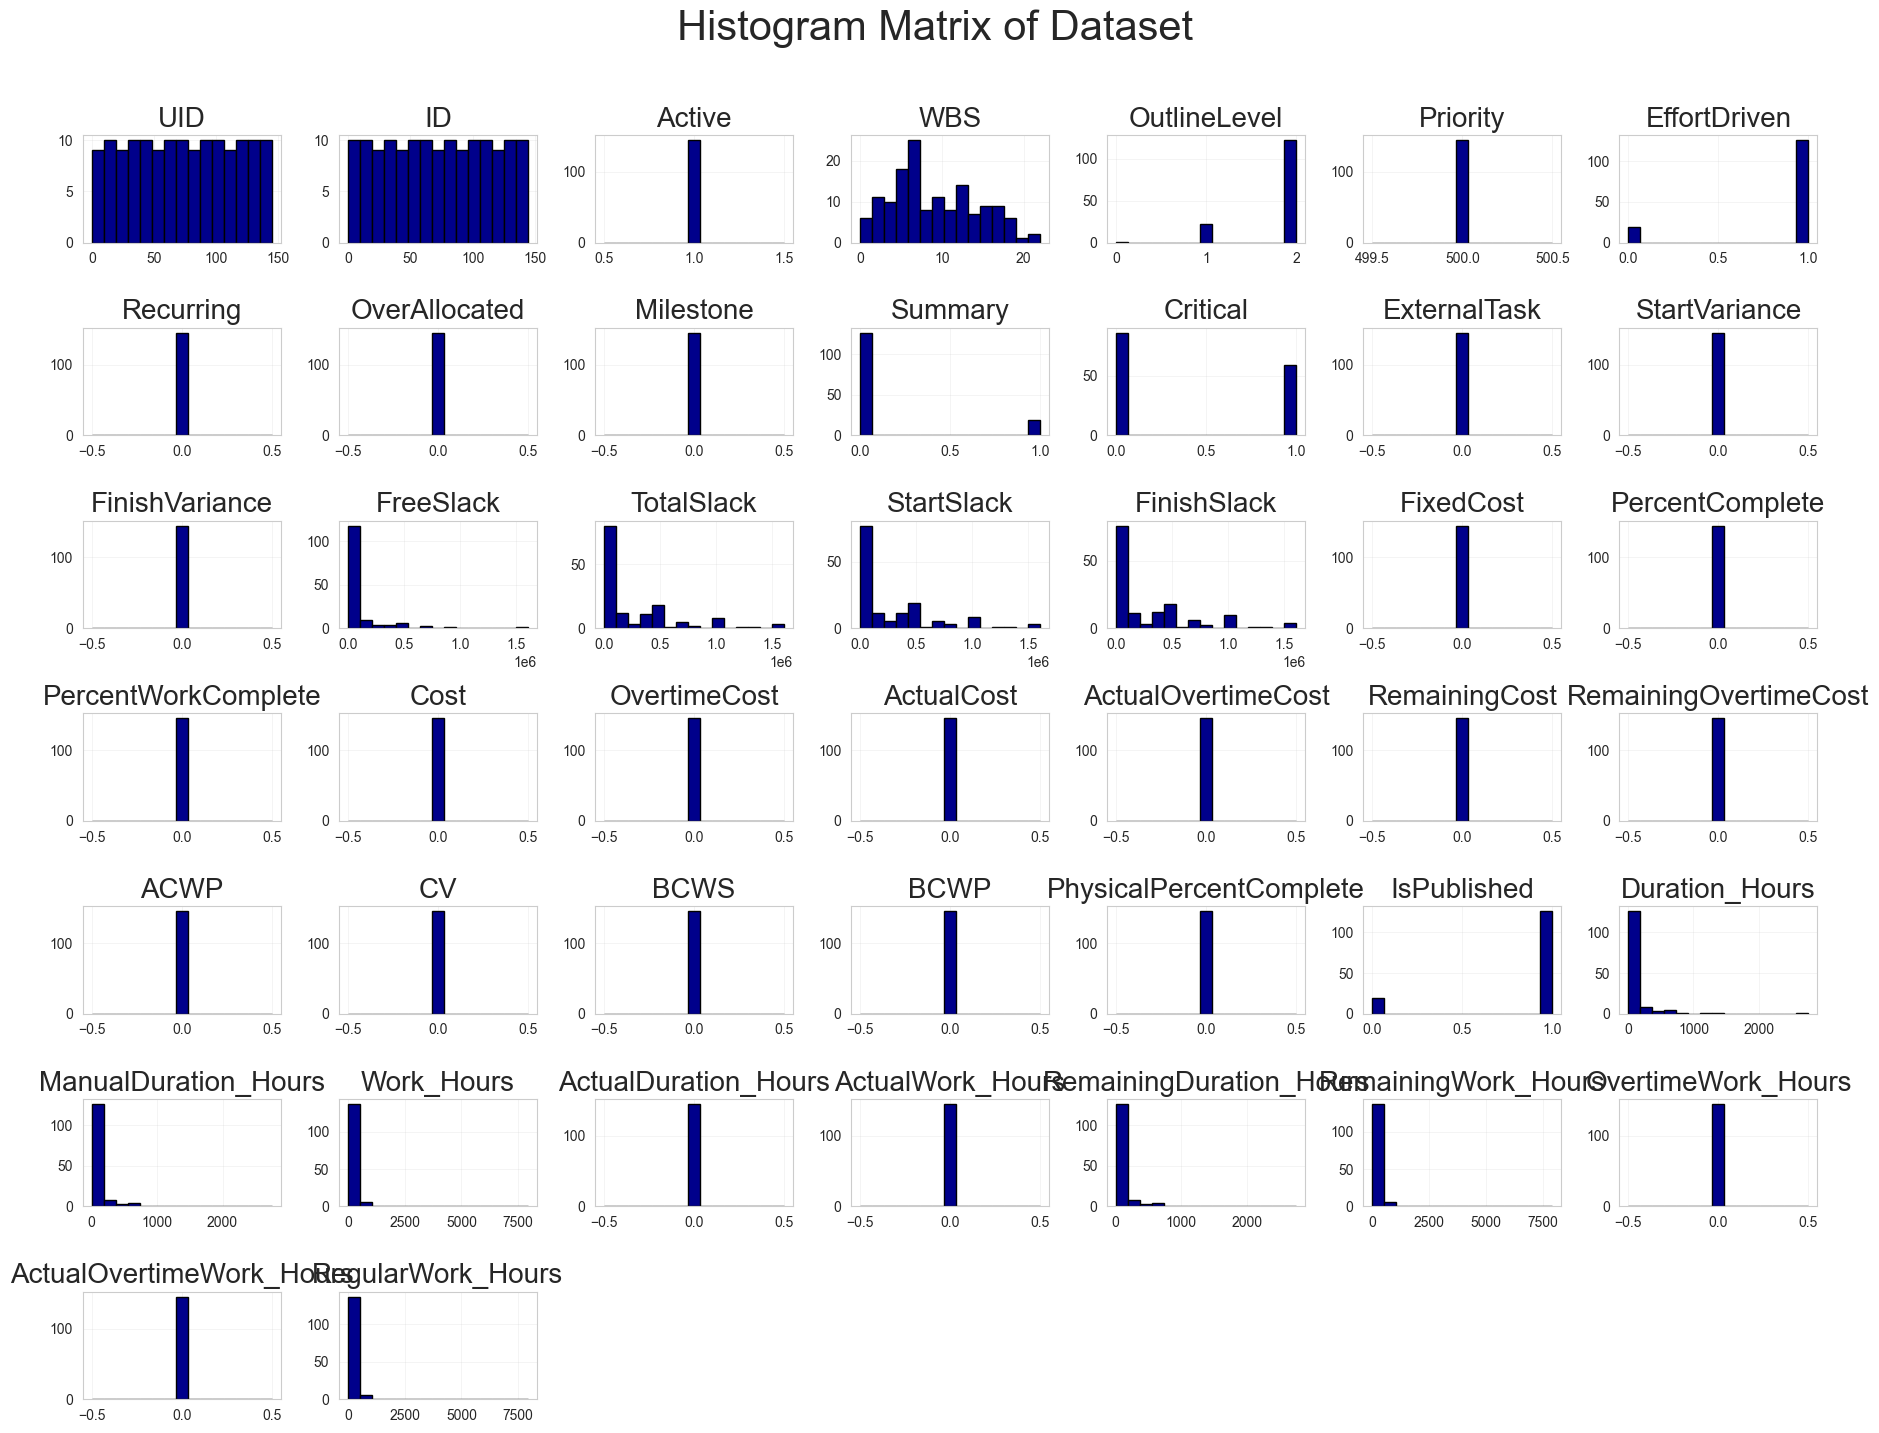

In [120]:
# -- Histogram Matrix for Dataset --

## pick numerical columns only
cost_df = processed_df.select_dtypes(include=[np.number])

# Set overall figure size (width, height)
axes = cost_df.hist(
    figsize=(18, 14),  # larger matrix
    bins=15, # adjust bin count
    color='darkblue',
    edgecolor='black',
    grid=False
)

# Loop over all subplots to format text and labels
for ax in axes.flatten():
    # Bigger titles and smaller axis labels
    ax.set_title(ax.get_title(), fontsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)

    ax.grid(alpha=0.3, linewidth=0.5) # thin gridlines for readability

plt.suptitle("Histogram Matrix of Dataset", fontsize=30, y=1.02)
plt.tight_layout()
plt.show()

Reviewing Cost Variables

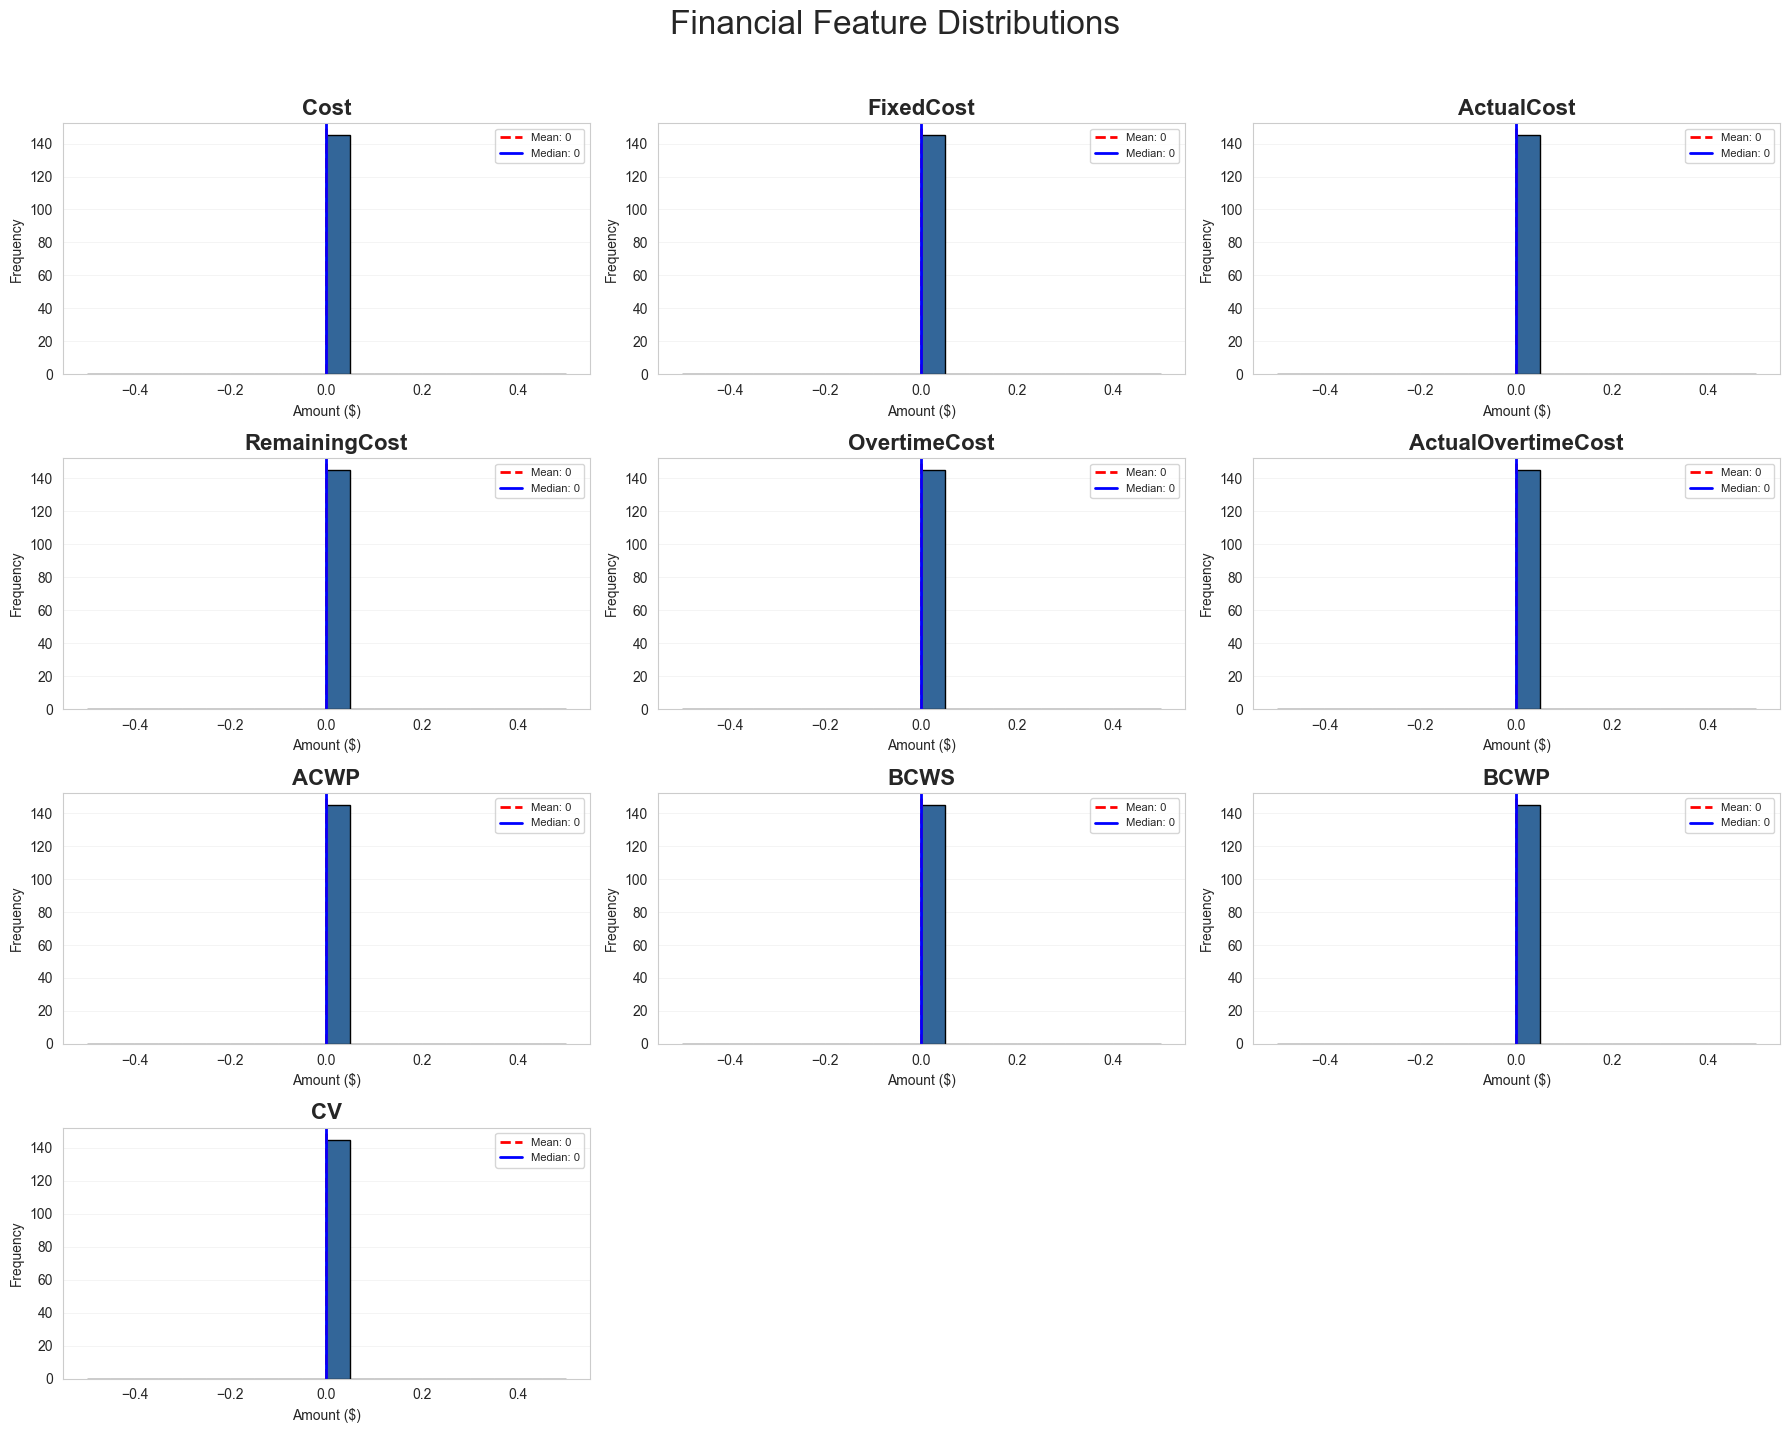

In [121]:
import numpy as np
import matplotlib.pyplot as plt

# -- 1. Select Specific Cost Columns --
# We define the list of financial features we care about
target_cols = [
    'Cost', 'FixedCost', 'ActualCost', 'RemainingCost', 
    'OvertimeCost', 'ActualOvertimeCost', 
    'ACWP', 'BCWS', 'BCWP', 'CV', 
    'FixedCostAccrual'
]

# Create a subset dataframe with only these columns (if they exist in your data)
# We also ensure they are numeric to avoid errors
plot_df = processed_df[[c for c in target_cols if c in processed_df.columns]].select_dtypes(include=[np.number])

# -- 2. Create Histogram Matrix --
# We use the Pandas built-in hist() method as you requested
axes = plot_df.hist(
    figsize=(18, 14),       # Large matrix size
    bins=20,                # Increased bins slightly for better detail
    color='#336699',        # Professional dark blue
    edgecolor='black',      # Black edges define the bars clearly
    grid=False,             # Turn off default grid (we add a custom one later)
    layout=(4, 3)           # Optional: Force a 4x3 grid layout (adjust based on count)
)

# -- 3. Format and Annotate --
# Flatten the 2D array of axes to a 1D list for easy looping
axes_flat = axes.flatten()

for i, ax in enumerate(axes_flat):
    # Check if this subplot actually contains a column (handle empty slots)
    if i < len(plot_df.columns):
        col_name = plot_df.columns[i]
        
        # Calculate Statistics
        mean_val = plot_df[col_name].mean()
        median_val = plot_df[col_name].median()
        
        # Add Vertical Lines for Mean (Red) and Median (Green)
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:,.0f}')
        ax.axvline(median_val, color='blue', linestyle='-', linewidth=2, label=f'Median: {median_val:,.0f}')
        
        # Formatting
        ax.set_title(col_name, fontsize=16, fontweight='bold')
        ax.set_xlabel("Amount ($)", fontsize=10)
        ax.set_ylabel("Frequency", fontsize=10)
        ax.grid(axis='y', alpha=0.3, linewidth=0.5) # Horizontal grid lines only
        ax.legend(loc='upper right', fontsize=8)    # Add legend for the lines
        
    else:
        # Hide empty subplots (if you have 10 columns in a 12-slot grid)
        ax.set_visible(False)

# -- 4. Final Touches --
plt.suptitle("Financial Feature Distributions", fontsize=24, y=1.02)
plt.tight_layout()
plt.show()

**Findings:** Most of the variables related to cost equal 0. Thus, they should be removed. 
 

### The removal of irrelevant variables:


In [122]:
# Remove/Drop irrelevant columns
print("Dataframe shape before dropping columns:", processed_df.shape)

cols_to_remove = [
    # 1. Target Leakage (Money components)
    "Cost","FixedCost", "FixedCostAccrual", "ActualCost", "RemainingCost",
    "OvertimeCost", "ActualOvertimeCost", "RemainingOvertimeCost",
    "ACWP", "BCWS", "BCWP", "CV",

    # 2. Future Data (Time Travel - things you don't know yet)
    "PercentComplete", "PercentWorkComplete", "PhysicalPercentComplete",
    "ActualDuration", "ActualWork", "ActualOvertimeWork",
    "RemainingDuration", "RemainingWork", "RemainingOvertimeWork",
    "ActualDuration_Hours", "ActualWork_Hours", "ActualOvertimeWork_Hours",
    "RemainingDuration_Hours", "RemainingWork_Hours",
    "StartVariance", "FinishVariance", "WorkVariance",
    "LevelingDelay", "LevelingDelayFormat", "LevelAssignments", "LevelingCanSplit",

    # 3. Redundant (Strings replaced by numeric _Hours)
    "Duration", "ManualDuration", "Work", "RegularWork", "OvertimeWork",
    "ManualDuration_Hours", "RegularWork_Hours", # Regular is redundant if we have Total & Overtime
    "OvertimeWork_Hours",

    # 4. Noise / Administrative
    "GUID", "ID", "WBS", "OutlineNumber", "CreateDate",
    "DurationFormat", "FreeformDurationFormat",
    "DisplayAsSummary", "HideBar", "Rollup",
    "EarnedValueMethod", "IsPublished", "CommitmentType",
    "CalendarUID", "ConstraintType", "IgnoreResourceCalendar",

    # 5. Dates (Noise for this specific model)
    "Start", "Finish", "ManualStart", "ManualFinish",
    "EarlyStart", "EarlyFinish", "LateStart", "LateFinish"
]

processed_df = processed_df.drop(columns=cols_to_remove, errors='ignore')
print("Dataframe shape after dropping columns:", processed_df.shape)

print("Remaining columns:")
print(processed_df.columns)

Dataframe shape before dropping columns: (145, 91)
Dataframe shape after dropping columns: (145, 26)
Remaining columns:
Index(['UID', 'Name', 'Active', 'Manual', 'Type', 'IsNull', 'OutlineLevel',
       'Priority', 'ResumeValid', 'EffortDriven', 'Recurring', 'OverAllocated',
       'Estimated', 'Milestone', 'Summary', 'Critical', 'IsSubproject',
       'IsSubprojectReadOnly', 'ExternalTask', 'FreeSlack', 'TotalSlack',
       'StartSlack', 'FinishSlack', 'Predecessors', 'Duration_Hours',
       'Work_Hours'],
      dtype='object')


In [123]:
# Convert Data Types Function

def convert_data_types(df):
    """
    Converts columns in the processed dataframe to their appropriate 
    statistical types (Numeric, Boolean, Categorical, String).
    """
    df_out = df

    # ---------------------------------------------------------
    # 1. IDENTIFIERS (Strings) - CHANGED
    # ---------------------------------------------------------
    # We treat UID as a string so the ML model doesn't think 
    # UID 100 is "bigger" than UID 1.
    id_cols = ['UID', 'Name', 'Predecessors']
    
    for col in id_cols:
        if col in df_out.columns:
            # Force to string type
            df_out[col] = df_out[col].astype(str)

    # ---------------------------------------------------------
    # 2. BOOLEAN FLAGS
    # ---------------------------------------------------------
    bool_cols = [
        'Active', 'Manual', 'IsNull', 'ResumeValid', 'EffortDriven', 
        'Recurring', 'OverAllocated', 'Estimated', 'Milestone', 
        'Summary', 'Critical', 'IsSubproject', 'IsSubprojectReadOnly', 
        'ExternalTask'
    ]
    
    for col in bool_cols:
        if col in df_out.columns:
            df_out[col] = pd.to_numeric(df_out[col], errors='coerce').fillna(0).astype(bool)

    # ---------------------------------------------------------
    # 3. NUMERIC (FLOAT)
    # ---------------------------------------------------------
    float_cols = [
        'Cost', 
        'FreeSlack', 'TotalSlack', 'StartSlack', 'FinishSlack',
        'Duration_Hours', 'Work_Hours', 'OvertimeWork_Hours'
    ]
    
    for col in float_cols:
        if col in df_out.columns:
            df_out[col] = pd.to_numeric(df_out[col], errors='coerce').fillna(0.0)

    # ---------------------------------------------------------
    # 4. NUMERIC (INT)
    # ---------------------------------------------------------
    # Removed UID from here
    int_cols = ['OutlineLevel', 'Priority']
    
    for col in int_cols:
        if col in df_out.columns:
            df_out[col] = pd.to_numeric(df_out[col], errors='coerce').fillna(0).astype(int)

    # ---------------------------------------------------------
    # 5. CATEGORICAL
    # ---------------------------------------------------------
    if 'Type' in df_out.columns:
        df_out['Type'] = df_out['Type'].astype('category')

    print("Data Type Conversion Complete.")
    print(df_out.dtypes)
    
    return df_out

convert_data_types(processed_df)

Data Type Conversion Complete.
UID                       object
Name                      object
Active                      bool
Manual                      bool
Type                    category
IsNull                      bool
OutlineLevel               int64
Priority                   int64
ResumeValid                 bool
EffortDriven                bool
Recurring                   bool
OverAllocated               bool
Estimated                   bool
Milestone                   bool
Summary                     bool
Critical                    bool
IsSubproject                bool
IsSubprojectReadOnly        bool
ExternalTask                bool
FreeSlack                  int64
TotalSlack                 int64
StartSlack                 int64
FinishSlack                int64
Predecessors              object
Duration_Hours           float64
Work_Hours               float64
dtype: object


,UID,Name,Active,Manual,Type,IsNull,OutlineLevel,Priority,ResumeValid,EffortDriven,...,IsSubproject,IsSubprojectReadOnly,ExternalTask,FreeSlack,TotalSlack,StartSlack,FinishSlack,Predecessors,Duration_Hours,Work_Hours
0,0,Commercial Construction,True,False,1,False,0,500,False,False,...,False,False,False,0,0,0,0,,2752.0,7929.600000
1,2,General Conditions,True,False,1,False,1,500,False,False,...,False,False,False,0,0,0,1569600,,136.0,193.600000
2,3,Receive notice to proceed and sign contract,True,False,0,False,2,500,False,True,...,False,False,False,0,0,0,0,,24.0,24.000000
3,4,Submit bond and insurance documents,True,False,0,False,2,500,False,True,...,False,False,False,0,1608000,1608000,1608000,3,16.0,20.000000
4,5,Prepare and submit project schedule,True,False,0,False,2,500,False,True,...,False,False,False,0,1608000,1608000,1608000,4,16.0,20.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,141,Perform Fire Marshal's inspection,True,False,0,False,2,500,False,True,...,False,False,False,0,0,0,0,140,8.0,8.000000
141,142,Complete punch list items from all inspections,True,False,0,False,1,500,False,True,...,False,False,False,0,0,0,0,141,80.0,79.200000
142,143,Obtain certificate of occupancy,True,False,0,False,1,500,False,True,...,False,False,False,0,0,0,0,142,16.0,16.000000
143,144,Issue final completion documents including war...,True,False,0,False,1,500,False,True,...,False,False,False,4800,4800,4800,4800,142,8.0,8.000000


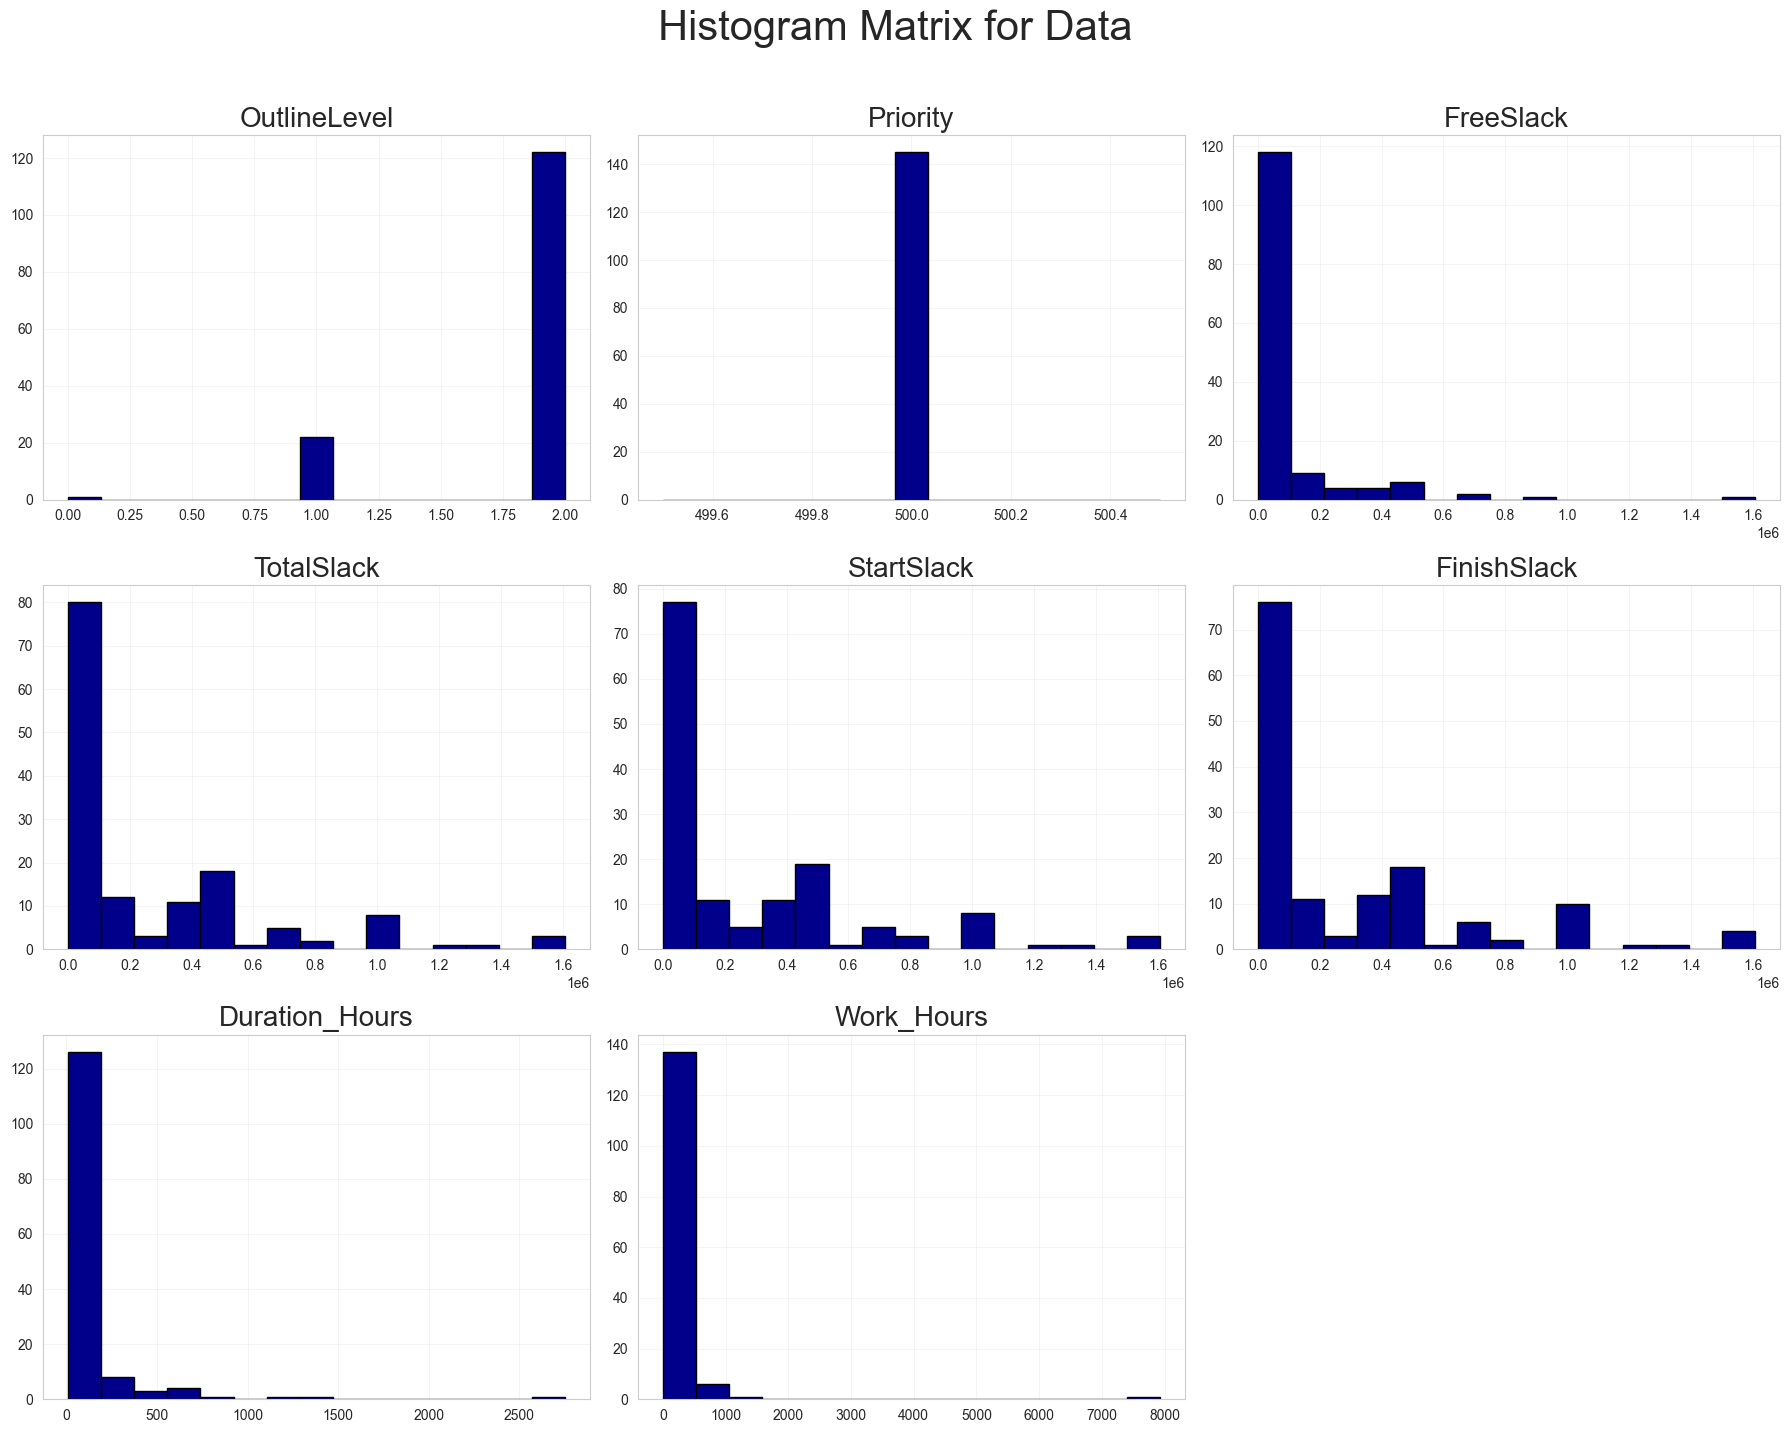

In [125]:
# -- Histogram Matrix for Dataset (Relevant Variables) --

#pick numerical columns only
numerical_df = processed_df.select_dtypes(include=[np.number])

# Set overall figure size (width, height)
axes = numerical_df.hist(
    figsize=(18, 14),  # larger matrix
    bins=15, # adjust bin count
    color='darkblue',
    edgecolor='black',
    grid=False
)

# Loop over all subplots to format text and labels
for ax in axes.flatten():
    # Bigger titles and smaller axis labels
    ax.set_title(ax.get_title(), fontsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)

    ax.grid(alpha=0.3, linewidth=0.5) # thin gridlines for readability

plt.suptitle("Histogram Matrix for Data", fontsize=30, y=1.02)
plt.tight_layout()
plt.show()

**Findings**
- The slack variables, particularly TotalSlack, are higher than 0, indicating their delay may not affect the project end date -> low risks. 
- Duration_hours (time for a task) and Work_Hours (man-hours required) are right-skewed, indicating most of the variables tend to be quite low. 

### Correlation Matrix
Target Variable - Output: Work_Hours

/var/folders/jy/6jqk_b8s32361qm39cwcxqy40000gn/T/ipykernel_26105/2864739197.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sorted_correlation.values, y=sorted_correlation.index, palette=colors)


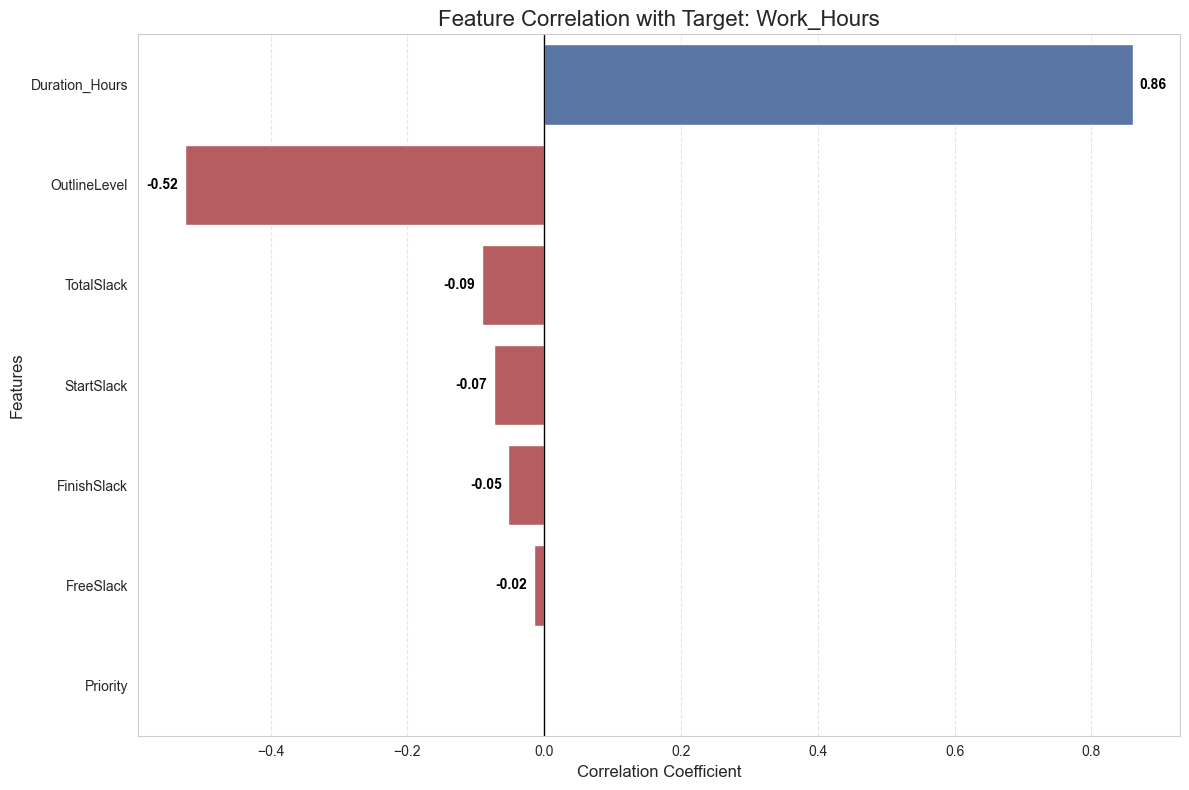

Duration_Hours    0.860134
OutlineLevel     -0.524849
TotalSlack       -0.090447
StartSlack       -0.074050
FinishSlack      -0.052271
FreeSlack        -0.015099
Priority               NaN
Name: Work_Hours, dtype: float64

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_target_correlation(df, target_col):
    """
    Calculates and visualizes the correlation of numerical features 
    with a specific target variable using a sorted bar chart.
    
    Args:
        df (pd.DataFrame): The dataset containing the features.
        target_col (str): The name of the target variable column.
        
    Returns:
        pd.Series: The sorted correlation values.
    """
    # 1. Select numerical columns only
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Check if target is valid
    if target_col not in numeric_df.columns:
        print(f"Error: Target '{target_col}' is not in the numeric columns.")
        return None

    # 2. Calculate Correlation Matrix
    correlation_matrix = numeric_df.corr()
    
    # 3. Isolate correlation with the target
    # Drop the target itself so we don't get a meaningless 1.0 bar
    correlation_with_target = correlation_matrix[target_col].drop(target_col)
    
    # 4. Sort by Absolute Value (Strength)
    # This ensures the most impactful features (whether + or -) are at the top
    sorted_correlation = correlation_with_target.loc[
        correlation_with_target.abs().sort_values(ascending=False).index
    ]
    
    # 5. Plotting
    plt.figure(figsize=(12, 8))
    
    # Create colors: Blue for Positive, Red for Negative
    colors = ['#4c72b0' if x > 0 else '#c44e52' for x in sorted_correlation.values]
    
    # Create Bar Chart
    ax = sns.barplot(x=sorted_correlation.values, y=sorted_correlation.index, palette=colors)
    
    # Formatting
    plt.title(f'Feature Correlation with Target: {target_col}', fontsize=16)
    plt.xlabel('Correlation Coefficient', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.axvline(0, color='black', linewidth=1) # Zero line
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Add values to the end of bars
    for i, v in enumerate(sorted_correlation.values):
        ax.text(v + (0.01 if v > 0 else -0.01), i, f'{v:.2f}', 
                va='center', ha='left' if v > 0 else 'right', 
                fontsize=10, fontweight='bold', color='black')

    plt.tight_layout()
    plt.show()
    
    return sorted_correlation

# --- Usage ---
# Copy this line to run it with your processed_df
# plot_target_correlation(processed_df, 'Work_Hours')

plot_target_correlation(processed_df, 'Work_Hours')

### Data Preprocessing (Before fitting into ML)

In [141]:
# Convert categorial columns to numeric using one-hot encoding
processed_df = pd.get_dummies(processed_df, drop_first=True)

# data shape
print("Processed DataFrame shape after one-hot encoding:", processed_df.shape)

Processed DataFrame shape after one-hot encoding: (145, 401)


## Linear Regression

In [139]:
df = processed_df

# Linear Regression
lin_reg = LinearRegression()
X = processed_df.drop(columns=["Work_Hours"])  # Features
y = processed_df["Work_Hours"]  # Target variable

lin_reg.fit(X, y)
y_pred = lin_reg.predict(X)

mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 4.945764252443571e-14


In [140]:
# Weights of each feature
feature_weights = pd.Series(lin_reg.coef_, index=X.columns)
print("Feature Weights:")
print(feature_weights)

Feature Weights:
Active                 8.142092e-07
Manual                -6.259469e-08
IsNull                -4.664855e-09
OutlineLevel          -1.360869e+02
Priority               1.091714e-12
                           ...     
Predecessors_95        3.573716e+01
Predecessors_95;101   -1.298802e+01
Predecessors_95;102    1.171616e+01
Predecessors_97;95    -4.091330e+01
Predecessors_99;96    -6.561747e+01
Length: 400, dtype: float64


## Neural Network Regression

In [127]:
#Pakckage installation for Neural Network

## Reinforcement Learning

In [128]:
#Pakckage installation for Reinforcement Learning


## Knowledge-based (KBSE)

In [129]:
# from collections.abc import Mapping
import experta
from experta import Fact, Field, KnowledgeEngine, Rule, TEST, MATCH


In [130]:

class Task(Fact):
    uid = Field(int, mandatory=True)
    name = Field(str, mandatory=True)
    duration_days = Field(float, mandatory=True)
    critical = Field(bool, mandatory=True)

class ScheduleEngine(KnowledgeEngine):

    @Rule(Task(duration_days=MATCH.d, critical=True),
          TEST(lambda d: d > 10))
    def long_critical_task(self, d):
        print(f"Critical task longer than 10 days: {d} days")

engine = ScheduleEngine()
engine.reset()
engine.declare(Task(uid=1, name="Excavation", duration_days=16, critical=True))
engine.run()


ValueError: Invalid value on field 'duration_days' for fact Task(uid=1, name='Excavation', duration_days=16, critical=True)